# Gradient boosting

### Each tree fixes what the last one got wrong

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How boosting differs from bagging, why fitting the residual is gradient descent in disguise, what the learning rate really trades against, and why boosting can overfit where a forest cannot |
| **You should already know** | [Random forests](../02-random-forest/) |
| **Datasets** | California Housing (20,640 × 8), UCI Dry Bean (13,611 × 16) |
| **Runtime** | Three to four minutes on a laptop CPU |
| **Next** | [04-06 XGBoost, LightGBM, CatBoost](../06-xgboost-lightgbm-catboost/) |

---

## 1. The idea

A [random forest](../02-random-forest/) grows hundreds of trees **in parallel**,
each on a different view of the data, and averages them. Every tree is trying to
solve the whole problem, and averaging cancels their independent mistakes.

Gradient boosting grows trees **in sequence**, and each one has a much smaller
job: predict the error the previous trees are still making.

1. Start by predicting the mean. It is wrong by some amount for every row.
2. Fit a small tree to those errors.
3. Add a fraction of its predictions to the running total.
4. Recompute the errors and repeat.

Every tree is a correction. The forest averages many complete answers; boosting
accumulates many small corrections. That difference decides everything else about
how the two behave.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X, y = datasets.california_housing()
print(f"{X.shape[0]:,} districts, {X.shape[1]} features")

20,640 districts, 8 features


## 2. Why "gradient"

The name looks like jargon bolted onto a simple idea, but it is exact.

For squared error, the loss on one row is $L = \tfrac{1}{2}(y - \hat{y})^2$. Its
derivative with respect to the prediction is:

$$\frac{\partial L}{\partial \hat{y}} = \hat{y} - y$$

which is the residual, negated. **Fitting the next tree to the residuals is
fitting it to the negative gradient of the loss.** Boosting is gradient descent,
except that each step is taken in the space of functions rather than the space of
parameters, and each step is a small tree.

Seen that way the learning rate means exactly what it means everywhere else: how
far to move along the gradient at each step.

Swap in a different loss and the residual changes to match. Absolute error gives
$\pm 1$, which is why boosting with absolute error resists outliers. Log loss
gives the classification version. The machinery does not change.

## 3. From scratch

For squared error the whole algorithm is about fifteen lines.

In [2]:
from sklearn.tree import DecisionTreeRegressor


class GradientBoostingScratch:
    """Gradient boosting for squared error, written out in full."""

    def __init__(self, n_trees=200, learning_rate=0.1, max_depth=3):
        self.n_trees = n_trees
        self.learning_rate = learning_rate
        self.max_depth = max_depth

    def fit(self, X, y, X_val=None, y_val=None):
        X, y = np.asarray(X, float), np.asarray(y, float)

        # Step 0: the best constant prediction is the mean.
        self.initial_ = y.mean()
        running = np.full(len(y), self.initial_)

        self.trees_ = []
        self.train_rmse_, self.val_rmse_ = [], []

        for _ in range(self.n_trees):
            residual = y - running               # the negative gradient

            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=0)
            tree.fit(X, residual)
            self.trees_.append(tree)

            # Take only a fraction of the step. This is the learning rate.
            running += self.learning_rate * tree.predict(X)

            self.train_rmse_.append(np.sqrt(np.mean((y - running) ** 2)))
            if X_val is not None:
                self.val_rmse_.append(np.sqrt(np.mean((y_val - self.predict(X_val)) ** 2)))
        return self

    def predict(self, X):
        X = np.asarray(X, float)
        out = np.full(len(X), self.initial_)
        for tree in self.trees_:
            out += self.learning_rate * tree.predict(X)
        return out


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.25, random_state=SEED)

mine = GradientBoostingScratch(n_trees=200, learning_rate=0.1).fit(
    X_train, y_train, X_test, y_test)

print(f"predicting the mean : RMSE {np.sqrt(np.mean((y_test - y_train.mean()) ** 2)):.4f}")
print(f"after 1 tree        : RMSE {mine.val_rmse_[0]:.4f}")
print(f"after 10 trees      : RMSE {mine.val_rmse_[9]:.4f}")
print(f"after 200 trees     : RMSE {mine.val_rmse_[-1]:.4f}")

predicting the mean : RMSE 1.1500
after 1 tree        : RMSE 1.0909
after 10 trees      : RMSE 0.8074
after 200 trees     : RMSE 0.5091


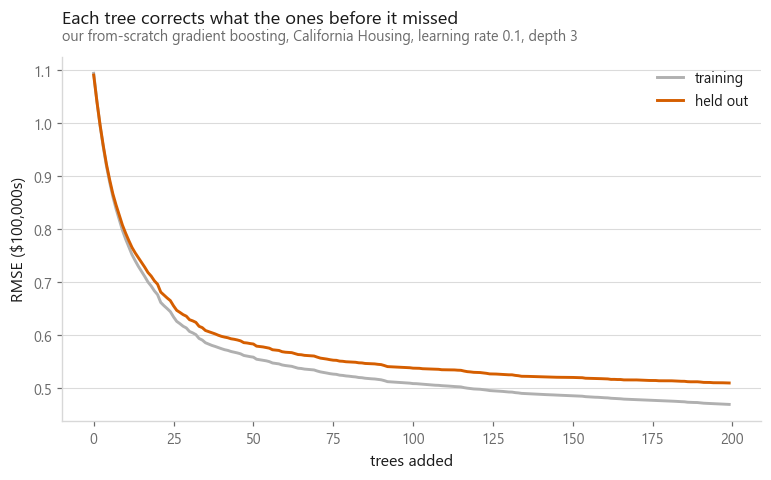

In [3]:
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.plot(mine.train_rmse_, color=style.NEUTRAL, label="training")
ax.plot(mine.val_rmse_, color=style.HIGHLIGHT, label="held out")
ax.set_xlabel("trees added")
ax.set_ylabel("RMSE ($100,000s)")
ax.legend()
style.title(ax, "Each tree corrects what the ones before it missed",
            "our from-scratch gradient boosting, California Housing, learning rate 0.1, depth 3")
style.save(fig, FIG / "fig-01-residual-fitting.png")

## 4. In practice

### The learning rate is a trade against the number of trees

The learning rate scales down every tree's contribution. Halve it and you need
roughly twice as many trees to travel the same distance, but the path is
smoother and generalises better, because no single tree gets to make a large
correction on its own.

 learning rate  best RMSE  trees needed  RMSE at 400
          0.50     0.4860           365       0.4869
          0.20     0.4715           388       0.4717
          0.10     0.4870           400       0.4870
          0.05     0.5080           400       0.5080


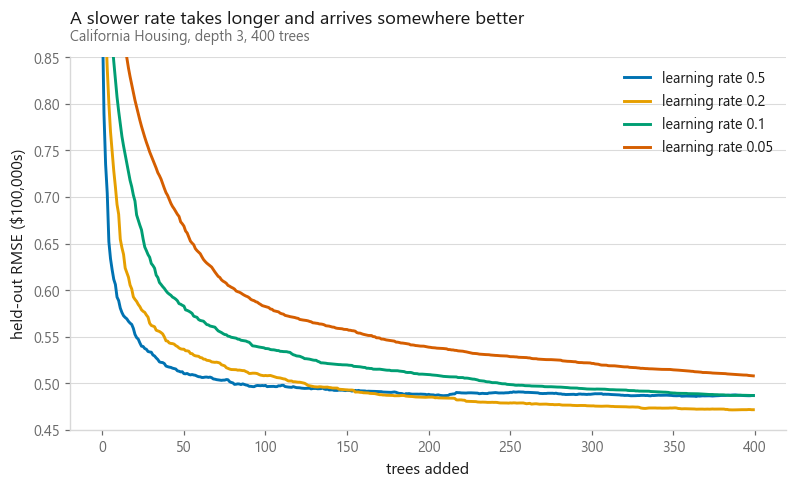

In [4]:
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

fig, ax = plt.subplots(figsize=(8.4, 4.4))
records = []

for rate, colour in zip([0.5, 0.2, 0.1, 0.05], style.PALETTE):
    model = GradientBoostingRegressor(n_estimators=400, learning_rate=rate,
                                      max_depth=3, random_state=SEED)
    model.fit(X_train, y_train)
    curve = [np.sqrt(mean_squared_error(y_test, pred))
             for pred in model.staged_predict(X_test)]
    ax.plot(curve, color=colour, label=f"learning rate {rate}")
    best_at = int(np.argmin(curve))
    records.append({"learning rate": rate, "best RMSE": min(curve),
                    "trees needed": best_at + 1, "RMSE at 400": curve[-1]})

ax.set_xlabel("trees added")
ax.set_ylabel("held-out RMSE ($100,000s)")
ax.set_ylim(0.45, 0.85)
ax.legend()
style.title(ax, "A slower rate takes longer and arrives somewhere better",
            "California Housing, depth 3, 400 trees")
style.save(fig, FIG / "fig-02-learning-rate.png")

print(pd.DataFrame(records).round(4).to_string(index=False))

### Boosting can overfit. A forest cannot.

This is the sharpest practical difference between the two. Adding trees to a
random forest never hurts, because it is averaging. Adding trees to a boosted
model eventually hurts, because it is still descending a gradient on the training
loss and will happily keep fitting noise.

boosting: best RMSE 0.4742 at 164 trees, 0.4799 at 900 trees (+0.0057)
forest  : 0.5209 at 200 trees, 0.5195 at 400


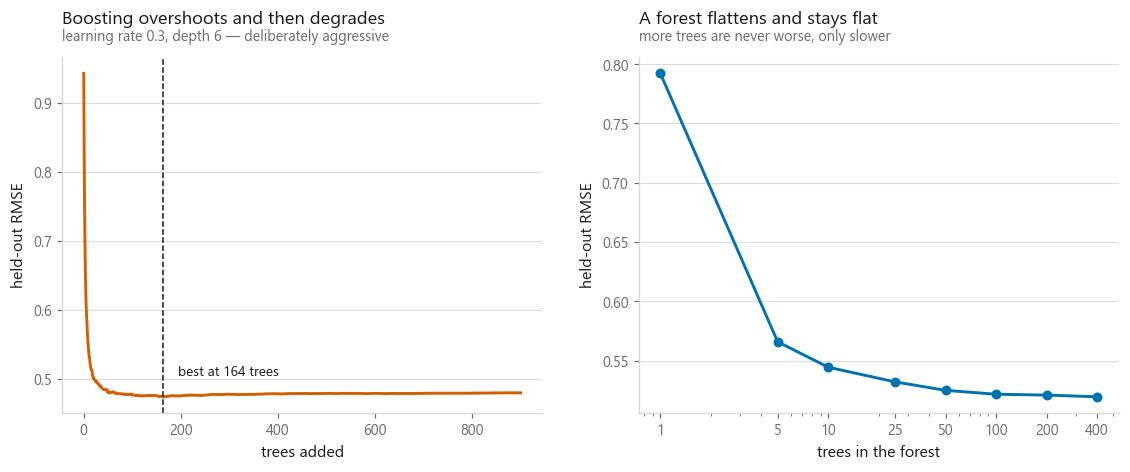

In [5]:
from sklearn.ensemble import RandomForestRegressor

deep = GradientBoostingRegressor(n_estimators=900, learning_rate=0.3, max_depth=6,
                                 random_state=SEED).fit(X_train, y_train)
boost_curve = [np.sqrt(mean_squared_error(y_test, pred)) for pred in deep.staged_predict(X_test)]

forest_counts = [1, 5, 10, 25, 50, 100, 200, 400]
forest_curve = []
for n in forest_counts:
    forest = RandomForestRegressor(n_estimators=n, n_jobs=-1, random_state=SEED)
    forest.fit(X_train, y_train)
    forest_curve.append(np.sqrt(mean_squared_error(y_test, forest.predict(X_test))))

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

axes[0].plot(boost_curve, color=style.HIGHLIGHT)
low = int(np.argmin(boost_curve))
axes[0].axvline(low, color=style.INK, ls="--", lw=1)
axes[0].annotate(f"best at {low + 1} trees", xy=(low, boost_curve[low]), xytext=(10, 14),
                 textcoords="offset points", fontsize=9, color=style.INK)
axes[0].set_xlabel("trees added")
axes[0].set_ylabel("held-out RMSE")
style.title(axes[0], "Boosting overshoots and then degrades",
            "learning rate 0.3, depth 6 — deliberately aggressive")

axes[1].plot(forest_counts, forest_curve, marker=style.MARKERS[0], color=style.PALETTE[0])
axes[1].set_xscale("log")
axes[1].set_xticks(forest_counts, [str(c) for c in forest_counts])
axes[1].set_xlabel("trees in the forest")
axes[1].set_ylabel("held-out RMSE")
style.title(axes[1], "A forest flattens and stays flat",
            "more trees are never worse, only slower")

style.save(fig, FIG / "fig-03-overfitting.png")

print(f"boosting: best RMSE {min(boost_curve):.4f} at {low + 1} trees, "
      f"{boost_curve[-1]:.4f} at 900 trees ({boost_curve[-1] - min(boost_curve):+.4f})")
print(f"forest  : {forest_curve[-2]:.4f} at 200 trees, {forest_curve[-1]:.4f} at 400")

The remedy is **early stopping**: hold out a slice, watch the validation loss, and
stop when it stops improving. Every serious boosting library does this for you,
and `HistGradientBoostingRegressor` has it switched on by default.

## 5. When it wins, when it loses

Against every model this book has built so far, on both a regression and a
classification dataset.

California Housing, RMSE (lower is better)
  linear regression   : 0.7263
  random forest       : 0.5025
  gradient boosting   : 0.4668

UCI Dry Bean, accuracy (higher is better)
  logistic regression : 0.9234
  random forest       : 0.9243
  gradient boosting   : 0.9271


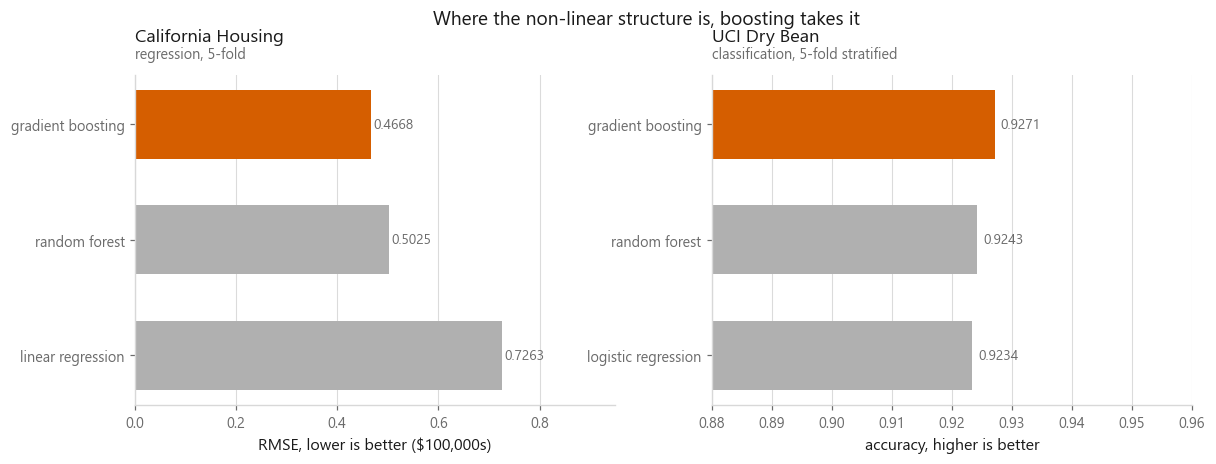

In [6]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

regression_folds = KFold(5, shuffle=True, random_state=SEED)
regressors = {
    "linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "random forest": RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEED),
    "gradient boosting": HistGradientBoostingRegressor(random_state=SEED),
}
regression_scores = {
    name: -cross_val_score(model, X.values, y.values, cv=regression_folds,
                           scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    for name, model in regressors.items()
}

X_bean, y_bean = datasets.dry_bean()
classification_folds = StratifiedKFold(5, shuffle=True, random_state=SEED)
classifiers = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "random forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "gradient boosting": HistGradientBoostingClassifier(random_state=SEED),
}
classification_scores = {
    name: cross_val_score(model, X_bean.values, y_bean.values,
                          cv=classification_folds, n_jobs=-1).mean()
    for name, model in classifiers.items()
}

fig, axes = plt.subplots(1, 2, figsize=(12.4, 3.9))

names = list(regression_scores)
axes[0].barh(names, [regression_scores[n] for n in names],
             color=[style.NEUTRAL, style.NEUTRAL, style.HIGHLIGHT], height=0.6)
for i, n in enumerate(names):
    axes[0].text(regression_scores[n] + 0.005, i, f"{regression_scores[n]:.4f}",
                 va="center", fontsize=9, color=style.MUTED)
axes[0].set_xlim(0, 0.95)
axes[0].set_xlabel("RMSE, lower is better ($100,000s)")
axes[0].grid(axis="y", visible=False); axes[0].grid(axis="x", visible=True)
style.title(axes[0], "California Housing", "regression, 5-fold")

names = list(classification_scores)
axes[1].barh(names, [classification_scores[n] for n in names],
             color=[style.NEUTRAL, style.NEUTRAL, style.HIGHLIGHT], height=0.6)
for i, n in enumerate(names):
    axes[1].text(classification_scores[n] + 0.001, i, f"{classification_scores[n]:.4f}",
                 va="center", fontsize=9, color=style.MUTED)
axes[1].set_xlim(0.88, 0.96)
axes[1].set_xlabel("accuracy, higher is better")
axes[1].grid(axis="y", visible=False); axes[1].grid(axis="x", visible=True)
style.title(axes[1], "UCI Dry Bean", "classification, 5-fold stratified")

fig.suptitle("Where the non-linear structure is, boosting takes it",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-comparison.png")

print("California Housing, RMSE (lower is better)")
for name, score in regression_scores.items():
    print(f"  {name:<20}: {score:.4f}")
print("\nUCI Dry Bean, accuracy (higher is better)")
for name, score in classification_scores.items():
    print(f"  {name:<20}: {score:.4f}")

Two datasets, two different stories, and the contrast is the point.

**California Housing** is where boosting earns its reputation. The relationship
between income, location and price is full of interactions and thresholds, and
the linear model left all of it on the table: the
[linear regression notebook](../../02-regression/01-linear-regression/) showed a
systematic bias of +0.33 on cheap districts and −0.96 on expensive ones for
exactly this reason. Boosting picks that structure up.

**Dry Bean** is where it does not. Boosting edges ahead of the random forest and
barely clears logistic regression, for the reason the
[random forest notebook](../02-random-forest/) established: bean measurements are
smooth correlated geometry, and there is very little non-linear structure to find.

This is the answer to "which algorithm should I use", and it is not a ranking.
**Gradient boosting is the strongest default for tabular data, and how much it
beats a linear model by is a property of your data, not of the algorithm.** On
one of these two datasets the gap is large. On the other it is almost nothing.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Tabular data with interactions and thresholds. It is the strongest default in this book for that case |
| **Avoid it when** | Images, audio, or text; you need to extrapolate outside the training range; you cannot afford to tune |
| **Scaling needed** | No. Trees split on thresholds |
| **Main dials** | `learning_rate` and `n_estimators` together, then `max_depth` (2 to 6 is usual), then subsampling |
| **Watch out** | It **will** overfit if you let it. Always use early stopping on a validation slice |
| **Versus a forest** | The forest is harder to get wrong; boosting is harder to beat once tuned |
| **Next** | [XGBoost, LightGBM, CatBoost](../06-xgboost-lightgbm-catboost/), which are this idea made fast |

## What to remember

1. Bagging averages many complete answers. Boosting accumulates many small
   corrections. Everything else follows from that.
2. Fitting the residual **is** fitting the negative gradient of squared error.
   The name is literal.
3. Learning rate and tree count trade against each other. Lower and more is
   almost always better than higher and fewer.
4. More trees eventually hurt a boosted model. Use early stopping.
5. Shallow trees, depth 2 to 6. Each one only has to fix a little.
6. How much boosting beats a linear model tells you about your data, not about
   boosting.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [04-06 XGBoost, LightGBM, CatBoost](../06-xgboost-lightgbm-catboost/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#GradientBoosting` `#XGBoost` `#LightGBM` `#Ensemble`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#Boosting`